In [25]:
from own_implementation import * 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, kstest 

In [26]:
## Parametry generatora LCG (Numerical Recipes)
a=1664525
c=1013904223
m=2**32

n=1000 
seed=42

In [27]:
lcg_numbers = LCG(a=a, c=c, m=m, seed=seed, n=n)
print(lcg_numbers)

[0.2523451747838408, 0.08812504541128874, 0.5772811982315034, 0.22255426598712802, 0.37566019711084664, 0.02566390484571457, 0.4472812858875841, 0.1184600037522614, 0.8738137057516724, 0.9946342753246427, 0.8532027236651629, 0.49967672815546393, 0.6420009464491159, 0.8614561874419451, 0.5964697764720768, 0.0907501564361155, 0.14020979800261557, 0.950088276527822, 0.9245554457884282, 0.8894689562730491, 0.5505083699245006, 0.1805165521800518, 0.5500854735728353, 0.2589667965658009, 0.9431216625962406, 0.8215009802952409, 0.15529390866868198, 0.8293947107158601, 0.4669222899246961, 0.060704877600073814, 0.02245523571036756, 0.5372887724079192, 0.8299602644983679, 0.8453321186825633, 0.6809180665295571, 0.38075808389112353, 0.5856568452436477, 0.6963971555233002, 0.7113653940614313, 0.7186180767603219, 0.9902874475810677, 0.44975284952670336, 0.09792640875093639, 0.1915941252373159, 0.4473786160815507, 0.12700111605226994, 0.7687648774590343, 0.5937204719521105, 0.8046440596226603, 0.3894

In [28]:
assert len(lcg_numbers) == n, "Błąd: Nieprawidłowa liczba wygenerowanych liczb."
assert all(0 <= x < 1 for x in lcg_numbers), "Błąd: Liczby nie są w zakresie (0, 1)."

# sprawdzenie równomierności rozkładu
max_range = 100  # liczba przedziałów dla testu chi-kwadrat
observed, _ = np.histogram(lcg_numbers, bins=max_range, range=(0, 1))
expected = np.full(max_range, n / max_range)
chi2, p = stats.chisquare(observed, expected)
print(f"Test chi-kwadrat: chi2 = {chi2:.2f}, p-value = {p:.4f}")
assert p > 0.05, "Błąd: Rozkład nie jest równomierny (p-value < 0.05)."

1000
Test chi-kwadrat: chi2 = 103.00, p-value = 0.3715


In [29]:
autocorr = np.corrcoef(lcg_numbers[:-1], lcg_numbers[1:])[0, 1]
print(f"Autokorelacja: {autocorr:.4f}")
assert abs(autocorr) < 0.1, "Błąd: Wysoka autokorelacja między kolejnymi liczbami."

Autokorelacja: -0.0362


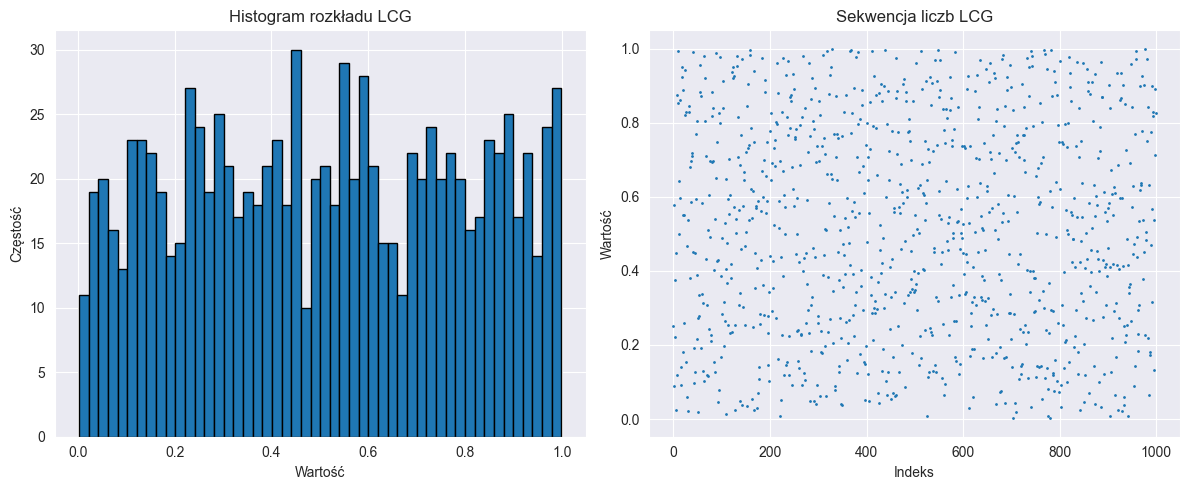

In [30]:
plt.figure(figsize=(12, 5))

# histogram
plt.subplot(1, 2, 1)
plt.hist(lcg_numbers, bins=50, edgecolor='black')
plt.title('Histogram rozkładu LCG')
plt.xlabel('Wartość')
plt.ylabel('Częstość')

# wyk. sekwencji
plt.subplot(1, 2, 2)
plt.scatter(range(n), lcg_numbers, s=1)
plt.title('Sekwencja liczb LCG')
plt.xlabel('Indeks')
plt.ylabel('Wartość')

plt.tight_layout()
plt.show()